# Rank-based Tests


### Two sample ranks

Suppose we compare two groups:

- Group A: $4, 100, 2, 3$
- Group B: $7, 5, 8, 6$

The raw mean for Group A is dominated by the single outlier. Move the widget slider below to change the outlier and compare two views of the same data: raw values and pooled ranks.

The rank-sum idea is: pool both groups, sort all observations, replace each value by its overall rank, then compare ranks between groups.


In [1]:
import ipywidgets as widgets

BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
GRAY = "#57606a"
DARK = "#24292f"
LIGHT = "#d8dee4"
GREEN = "#1a7f37"

def _mean(values):
    return sum(values) / len(values)

def _fmt(value):
    return str(int(value)) if float(value).is_integer() else f"{value:.2f}"

def _text(x, y, label, size=14, fill=DARK, weight="400", anchor="start"):
    return (
        f'<text x="{x}" y="{y}" font-size="{size}" fill="{fill}" '
        f'font-weight="{weight}" text-anchor="{anchor}">{label}</text>'
    )

def _circle(x, y, color, label):
    return (
        f'<circle cx="{x:.1f}" cy="{y:.1f}" r="10" fill="{color}" '
        f'stroke="white" stroke-width="2" />'
        + _text(f"{x:.1f}", f"{y - 18:.1f}", label, size=13, fill=color, weight="700", anchor="middle")
    )

def _rank_widget_html(outlier):
    group_a = [4, outlier, 2, 3]
    group_b = [7, 5, 8, 6]
    max_value = max(max(group_a + group_b), 20)

    x0, x1 = 58, 400
    axis_y = 220

    def scale(value):
        return x0 + value / max_value * (x1 - x0)

    raw_parts = [
        _text(20, 32, f"mean(A) = {_fmt(_mean(group_a))}", fill=BLUE, weight="700"),
        _text(250, 32, f"mean(B) = {_fmt(_mean(group_b))}", fill=ORANGE, weight="700"),
        _text(16, 90, "A", size=18, fill=BLUE, weight="700"),
        _text(16, 160, "B", size=18, fill=ORANGE, weight="700"),
        f'<line x1="{x0}" y1="{axis_y}" x2="{x1}" y2="{axis_y}" stroke="{GRAY}" stroke-width="2" />',
    ]
    for tick in [0, round(max_value / 2), max_value]:
        x = scale(tick)
        raw_parts.append(f'<line x1="{x:.1f}" y1="{axis_y - 6}" x2="{x:.1f}" y2="{axis_y + 6}" stroke="{GRAY}" stroke-width="2" />')
        raw_parts.append(_text(f"{x:.1f}", axis_y + 25, tick, size=13, fill=GRAY, anchor="middle"))
    for i, value in enumerate(group_a):
        raw_parts.append(_circle(scale(value), 94 + (i % 2) * 10, BLUE, value))
    for i, value in enumerate(group_b):
        raw_parts.append(_circle(scale(value), 164 + (i % 2) * 10, ORANGE, value))

    pooled = sorted(
        [{"value": value, "group": "A"} for value in group_a]
        + [{"value": value, "group": "B"} for value in group_b],
        key=lambda item: item["value"],
    )
    rank_parts = [
        _text(10, 50, "value", fill=GRAY),
        _text(10, 114, "group", fill=GRAY),
        _text(10, 178, "rank", fill=GRAY),
    ]
    rank_a, rank_b = [], []
    xs = [44 + i * 52 for i in range(len(pooled))]
    for rank, (x, item) in enumerate(zip(xs, pooled), start=1):
        color = BLUE if item["group"] == "A" else ORANGE
        if item["group"] == "A":
            rank_a.append(rank)
        else:
            rank_b.append(rank)
        rank_parts.append(_text(x, 50, item["value"], size=16, fill=color, weight="700", anchor="middle"))
        rank_parts.append(f'<rect x="{x - 18}" y="84" width="36" height="36" rx="6" fill="{color}" />')
        rank_parts.append(_text(x, 108, item["group"], size=18, fill="white", weight="700", anchor="middle"))
        rank_parts.append(_text(x, 178, rank, size=16, weight="700", anchor="middle"))
        if rank < len(pooled):
            rank_parts.append(f'<line x1="{x + 22}" y1="102" x2="{xs[rank] - 22}" y2="102" stroke="{LIGHT}" stroke-width="4" />')
    rank_parts.append(_text(44, 232, f"avg rank(A) = {_fmt(_mean(rank_a))}", fill=BLUE, weight="700"))
    rank_parts.append(_text(235, 232, f"avg rank(B) = {_fmt(_mean(rank_b))}", fill=ORANGE, weight="700"))

    return f"""
    <div style="font-family: Arial, Helvetica, sans-serif; max-width: 980px; border: 1px solid #d0d7de; border-radius: 8px; padding: 16px; background: #ffffff;">
      <div style="font-size:24px; font-weight:700; margin-bottom:4px;">Two-sample rank widget</div>
      <div style="color:{GRAY}; font-size:15px; margin-bottom:14px;">The slider is an ipywidgets control. It changes Group A's outlier and redraws both panels.</div>
      <div style="display:grid; grid-template-columns:1fr 1fr; gap:14px;">
        <div style="border:1px solid #d8dee4; border-radius:8px; padding:12px;">
          <div style="font-weight:700; font-size:18px;">Raw values</div>
          <div style="font-size:14px; line-height:1.55; margin-top:6px;">
            <span style="color:{BLUE};"><b>Group A:</b> 4, {outlier}, 2, 3</span><br>
            <span style="color:{ORANGE};"><b>Group B:</b> 7, 5, 8, 6</span>
          </div>
          <svg viewBox="0 0 440 260" width="100%" height="260" role="img" aria-label="Raw values by group">{''.join(raw_parts)}</svg>
        </div>
        <div style="border:1px solid #d8dee4; border-radius:8px; padding:12px;">
          <div style="font-weight:700; font-size:18px;">Pooled ranks</div>
          <div style="font-size:14px; margin-top:6px; color:{GRAY};">Sort A and B together, then replace values by ranks.</div>
          <svg viewBox="0 0 440 260" width="100%" height="260" role="img" aria-label="Pooled ranks">{''.join(rank_parts)}</svg>
        </div>
      </div>
      <div style="margin-top:14px; padding:12px; border-radius:8px; background:#f6f8fa; font-size:16px;">
        <b>Takeaway:</b> the outlier is still the largest observation, so it gets the largest rank. But changing it from {outlier} to something even larger would not give it more than the largest rank. <span style="color:{GREEN}; font-weight:700;">Ranks bound the influence of one extreme raw value.</span>
      </div>
    </div>
    """

outlier_slider = widgets.IntSlider(
    value=100,
    min=8,
    max=200,
    step=1,
    description="Group A outlier",
    continuous_update=True,
    style={"description_width": "initial"},
    layout=widgets.Layout(width="440px"),
)
rank_panel = widgets.HTML(value=_rank_widget_html(outlier_slider.value))

def redraw_rank_widget(change=None):
    rank_panel.value = _rank_widget_html(outlier_slider.value)

outlier_slider.observe(redraw_rank_widget, names="value")
widgets.VBox([outlier_slider, rank_panel])



### 2 Formal Definition of Rank

In a single sample of $n$ observations, the **rank** of an observation $x_i$ is, for $i=1,2,\ldots, n$,

$$R_i \;=\; 1 + \left|\{j : x_j \lt x_i,\; j \ne i\}\right|.$$

In words: count how many observations are smaller than $x_i$, then add $1$.


\begin{array}{c|cccccccc}
\textbf{Observation}\  x_i &  34 & 12 & 45 & 23 & 18 & 40 & 29 & 7\\\hline
\textbf{Rank}\  R_i       & 6  & 2  & 8  & 4  & 3  & 7  & 5  & 1
\end{array}

### 3 Parametric Tests vs. Nonparametric Tests


Parametric tests require parametric assumptions, while nonparametric tests avoid some of those assumptions by using ranks instead of raw values. For similar hypotheses, a parametric test is usually more efficient when its assumptions are true, while a rank-based test is more robust when those assumptions are violated.

We will compare a **two-sample t-test** and a **Mann-Whitney U test** (also called the Wilcoxon rank-sum test).

- Data: two independent groups, $X_1,\dots,X_m$ and $Y_1,\dots,Y_n$
- Null hypothesis: the two groups come from the same distribution
- Rank-sum idea: pool the two groups, rank all observations together, then compare the ranks assigned to each group

For one group, sum its pooled ranks:

$$R_X = \sum_{i=1}^{m} R_i.$$

The Mann-Whitney statistic is the rank-sum after subtracting the smallest possible rank-sum for that group:

$$U_X = R_X - \frac{m(m+1)}{2}.$$

In the simulation below, each group has sample size $n = 25$. Under $H_0$, both groups are centered at $0$. Under $H_1$, Group B is shifted by $0.6$. We vary tail heaviness using Student-$t$ distributions:

- degrees-of-freedom $\mathrm{df} = \infty, 30, 15, 10, 5, 3$
- smaller $\mathrm{df}$ means heavier tails and more extreme outliers

We compute two quantities:

- Type I error rate: fraction of $p < \alpha$ under $H_0$
- Power: fraction of $p < \alpha$ under $H_1$


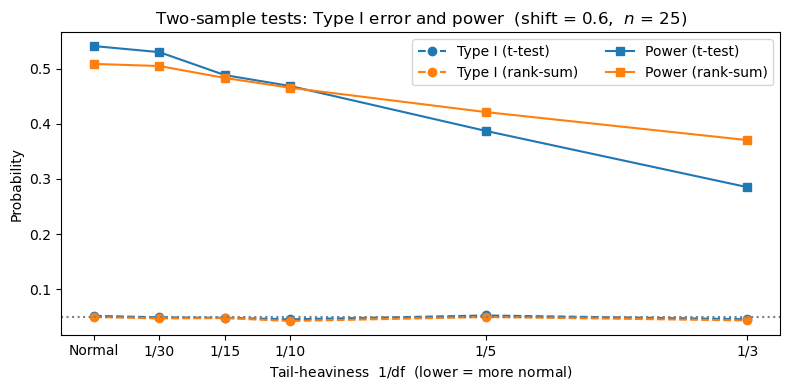

In [2]:
import numpy as np, scipy.stats as st, matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 25
alpha = 0.05
reps = 5000
shift = 0.6
dfs = [np.inf, 30, 15, 10, 5, 3]

type1_t = []
type1_rank = []
power_t = []
power_rank = []

for df in dfs:
    if np.isinf(df):
        x0 = rng.normal(0, 1, (reps, n))
        y0 = rng.normal(0, 1, (reps, n))
        x1 = rng.normal(0, 1, (reps, n))
        y1 = rng.normal(shift, 1, (reps, n))
    else:
        x0 = rng.standard_t(df, (reps, n))
        y0 = rng.standard_t(df, (reps, n))
        x1 = rng.standard_t(df, (reps, n))
        y1 = rng.standard_t(df, (reps, n)) + shift

    p_t0 = st.ttest_ind(x0, y0, axis=1, equal_var=False).pvalue
    p_t1 = st.ttest_ind(x1, y1, axis=1, equal_var=False).pvalue

    p_rank0 = np.array([st.mannwhitneyu(a, b, alternative="two-sided").pvalue for a, b in zip(x0, y0)])
    p_rank1 = np.array([st.mannwhitneyu(a, b, alternative="two-sided").pvalue for a, b in zip(x1, y1)])

    type1_t.append((p_t0 < alpha).mean())
    type1_rank.append((p_rank0 < alpha).mean())
    power_t.append((p_t1 < alpha).mean())
    power_rank.append((p_rank1 < alpha).mean())

tail = [0 if np.isinf(df) else 1 / df for df in dfs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tail, type1_t, "o--", label="Type I (t-test)", color="C0")
ax.plot(tail, type1_rank, "o--", label="Type I (rank-sum)", color="C1")
ax.axhline(alpha, ls=":", color="grey")

ax.plot(tail, power_t, "s-", label="Power (t-test)", color="C0")
ax.plot(tail, power_rank, "s-", label="Power (rank-sum)", color="C1")

ax.set_xticks(tail)
ax.set_xticklabels(["Normal"] + [f"1/{df}" for df in dfs[1:]])
ax.set_xlabel(r"Tail-heaviness  $1/\mathrm{df}$  (lower = more normal)")
ax.set_ylabel("Probability")
ax.set_title(fr"Two-sample tests: Type I error and power  (shift = {shift},  $n$ = {n})")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


### 4 Canonical rank-based tests  
| Test | Data structure | Null hypothesis $H_0$ | Test statistic (schematic) | Typical assumptions |
|------|---------------|-------------------------|---------------------------|---------------------|
| **Wilcoxon signed-rank** | One sample / paired | Median difference = 0 | $ W = \sum R_i^+ $ | Symmetric distribution of differences |
| **Mann-Whitney / Wilcoxon rank-sum** | Two independent samples | Same distribution | $ U = R_X - m(m+1)/2 $ | Continuous, independent samples |
| **Kruskal-Wallis** | More than two groups | All groups have the same distribution | Compare group rank sums | Independent samples, similar shape |
| **Spearman correlation** | Two numeric vectors | No monotone association | Pearson correlation of ranks | Paired observations, monotone relationship |
